### Final Project

First I will import the modules for my final project. These modules will help me to analyze the performance of three influential companies OpenAI, Apple, and Palantir. Apple and Palantir are publicly traded companies, while OpenAI will be used as a reference point to examine how major news headlines may influence public perception of a company’s value and broader market sentiment.

In [ ]:
import os
import requests
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sqlalchemy import create_engine
from datetime import datetime
from urllib.parse import quote_plus
os.environ["NEWS_API_KEY"] = 

### Next I will call the news api to parse news data for future analysis

In [13]:
NEWS_API_KEY = os.getenv("NEWS_API_KEY")

### Next I will outline the companies I want to search for news and stock data along with the time query timeline

In [22]:
tickers = {
    "Apple": "AAPL",
    "Palantir": "PLTR"
}

news_queries = {
    "OpenAI": "OpenAI",
    "Apple": "Apple stock OR Apple AI OR AAPL",
    "Palantir": "Palantir stock OR PLTR OR Palantir AI"
}

start_date = "2026-04-27"
end_date = "2026-04-29"

companies_df = pd.DataFrame([
    {"company_id": 1, "company_name": "Apple", "ticker": "AAPL", "is_public": True},
    {"company_id": 2, "company_name": "Palantir", "ticker": "PLTR", "is_public": True},
    {"company_id": 3, "company_name": "OpenAI", "ticker": None, "is_public": False}
])

companies_df

,company_id,company_name,ticker,is_public
0,1,Apple,AAPL,True
1,2,Palantir,PLTR,True
2,3,OpenAI,None,False


### Now I will query yahoo finance for stock data

In [32]:
all_prices = []

for company, ticker in tickers.items():
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1h",
        auto_adjust=False
    )

    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()

    df["company"] = company
    df["ticker"] = ticker

    # Keep only the columns needed for analysis
    df = df[[
        "Datetime",
        "company",
        "ticker",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]]

    all_prices.append(df)

stock_prices_df = pd.concat(all_prices, ignore_index=True)

stock_prices_df.head()

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


Price,Datetime,company,ticker,Open,High,Low,Close,Volume
0,2026-04-27 13:30:00+00:00,Apple,AAPL,266.089996,268.359985,265.070007,267.359985,10219067
1,2026-04-27 14:30:00+00:00,Apple,AAPL,267.390015,267.799988,266.619995,267.109985,3251687
2,2026-04-27 15:30:00+00:00,Apple,AAPL,267.140015,267.640015,266.260010,266.295013,2679704
3,2026-04-27 16:30:00+00:00,Apple,AAPL,266.290009,267.029999,266.290009,266.839996,2950643
4,2026-04-27 17:30:00+00:00,Apple,AAPL,266.829987,267.049988,266.089996,266.349915,2558668


### Next I will leverage the news api for news information for these companies and print the data for analysis

In [24]:
def get_news(query, from_date, to_date):
    url = "https://newsapi.org/v2/everything"

    params = {
        "q": query,
        "from": from_date,
        "to": to_date,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": 100,
        "apiKey": NEWS_API_KEY
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print("Status Code:", response.status_code)
        print("Response:", response.text)

    response.raise_for_status()
    return response.json().get("articles", [])


all_articles = []

for company, query in news_queries.items():
    articles = get_news(query, start_date, end_date)

    for article in articles:
        all_articles.append({
            "company": company,
            "title": article.get("title"),
            "description": article.get("description"),
            "source": article.get("source", {}).get("name"),
            "published_at": article.get("publishedAt"),
            "url": article.get("url")
        })

news_df = pd.DataFrame(all_articles)

news_df.head()

,company,title,description,source,published_at,url
0,OpenAI,Meta is still burning money on AR/VR | TechCrunch,Meta is losing billions on Reality Labs each q...,TechCrunch,2026-04-29T23:58:26Z,https://techcrunch.com/2026/04/29/meta-is-stil...
1,OpenAI,Meta is still burning money on AR/VR,Meta is losing billions on Reality Labs each q...,Yahoo Entertainment,2026-04-29T23:58:26Z,https://finance.yahoo.com/markets/stocks/artic...
2,OpenAI,Satya Nadella says he's ready to 'exploit' the...,Microsoft gets to offer OpenAI's tech to its c...,TechCrunch,2026-04-29T23:55:23Z,https://techcrunch.com/2026/04/29/satya-nadell...
3,OpenAI,openai_agents_agentmesh 3.2.2,AgentMesh trust layer for OpenAI Agents SDK — ...,Pypi.org,2026-04-29T23:49:03Z,https://pypi.org/project/openai-agents-agentme...
4,OpenAI,openai_agents_agentmesh added to PyPI,AgentMesh trust layer for OpenAI Agents SDK — ...,Pypi.org,2026-04-29T23:49:03Z,https://pypi.org/project/openai_agents_agentmesh/


### Now I will build code to analyze the sentiment this news data is commiting

In [25]:
news_df["published_at"] = pd.to_datetime(news_df["published_at"])

news_df["combined_text"] = (
    news_df["title"].fillna("") + " " +
    news_df["description"].fillna("")
)

news_df = news_df.merge(
    companies_df[["company_id", "company_name"]],
    left_on="company",
    right_on="company_name",
    how="left"
)

news_df.head()

,company,title,description,source,published_at,url,combined_text,company_id,company_name
0,OpenAI,Meta is still burning money on AR/VR | TechCrunch,Meta is losing billions on Reality Labs each q...,TechCrunch,2026-04-29 23:58:26+00:00,https://techcrunch.com/2026/04/29/meta-is-stil...,Meta is still burning money on AR/VR | TechCru...,3,OpenAI
1,OpenAI,Meta is still burning money on AR/VR,Meta is losing billions on Reality Labs each q...,Yahoo Entertainment,2026-04-29 23:58:26+00:00,https://finance.yahoo.com/markets/stocks/artic...,Meta is still burning money on AR/VR Meta is l...,3,OpenAI
2,OpenAI,Satya Nadella says he's ready to 'exploit' the...,Microsoft gets to offer OpenAI's tech to its c...,TechCrunch,2026-04-29 23:55:23+00:00,https://techcrunch.com/2026/04/29/satya-nadell...,Satya Nadella says he's ready to 'exploit' the...,3,OpenAI
3,OpenAI,openai_agents_agentmesh 3.2.2,AgentMesh trust layer for OpenAI Agents SDK — ...,Pypi.org,2026-04-29 23:49:03+00:00,https://pypi.org/project/openai-agents-agentme...,openai_agents_agentmesh 3.2.2 AgentMesh trust ...,3,OpenAI
4,OpenAI,openai_agents_agentmesh added to PyPI,AgentMesh trust layer for OpenAI Agents SDK — ...,Pypi.org,2026-04-29 23:49:03+00:00,https://pypi.org/project/openai_agents_agentmesh/,openai_agents_agentmesh added to PyPI AgentMes...,3,OpenAI


In [26]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(str(text))["compound"]

news_df["sentiment_score"] = news_df["combined_text"].apply(get_sentiment)

def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

news_df["sentiment_label"] = news_df["sentiment_score"].apply(label_sentiment)

news_df.head()

,company,title,description,source,published_at,url,combined_text,company_id,company_name,sentiment_score,sentiment_label
0,OpenAI,Meta is still burning money on AR/VR | TechCrunch,Meta is losing billions on Reality Labs each q...,TechCrunch,2026-04-29 23:58:26+00:00,https://techcrunch.com/2026/04/29/meta-is-stil...,Meta is still burning money on AR/VR | TechCru...,3,OpenAI,-0.0772,Negative
1,OpenAI,Meta is still burning money on AR/VR,Meta is losing billions on Reality Labs each q...,Yahoo Entertainment,2026-04-29 23:58:26+00:00,https://finance.yahoo.com/markets/stocks/artic...,Meta is still burning money on AR/VR Meta is l...,3,OpenAI,-0.0772,Negative
2,OpenAI,Satya Nadella says he's ready to 'exploit' the...,Microsoft gets to offer OpenAI's tech to its c...,TechCrunch,2026-04-29 23:55:23+00:00,https://techcrunch.com/2026/04/29/satya-nadell...,Satya Nadella says he's ready to 'exploit' the...,3,OpenAI,0.1858,Positive
3,OpenAI,openai_agents_agentmesh 3.2.2,AgentMesh trust layer for OpenAI Agents SDK — ...,Pypi.org,2026-04-29 23:49:03+00:00,https://pypi.org/project/openai-agents-agentme...,openai_agents_agentmesh 3.2.2 AgentMesh trust ...,3,OpenAI,0.5106,Positive
4,OpenAI,openai_agents_agentmesh added to PyPI,AgentMesh trust layer for OpenAI Agents SDK — ...,Pypi.org,2026-04-29 23:49:03+00:00,https://pypi.org/project/openai_agents_agentmesh/,openai_agents_agentmesh added to PyPI AgentMes...,3,OpenAI,0.5106,Positive


### Next I will normalize the data to make future analysis easier

In [27]:
sentiment_scores_df = news_df[[
    "company_id",
    "url",
    "sentiment_score",
    "sentiment_label"
]].copy()

news_articles_df = news_df[[
    "company_id",
    "company",
    "title",
    "description",
    "source",
    "published_at",
    "url"
]].copy()

sentiment_scores_df.head()

,company_id,url,sentiment_score,sentiment_label
0,3,https://techcrunch.com/2026/04/29/meta-is-stil...,-0.0772,Negative
1,3,https://finance.yahoo.com/markets/stocks/artic...,-0.0772,Negative
2,3,https://techcrunch.com/2026/04/29/satya-nadell...,0.1858,Positive
3,3,https://pypi.org/project/openai-agents-agentme...,0.5106,Positive
4,3,https://pypi.org/project/openai_agents_agentmesh/,0.5106,Positive


### Now I will save the normalized data into a database using sqlalchemy a python sql toolkit. This will help with the analysis of stock performance to news

In [28]:
engine = create_engine("sqlite:///final_project_stock_news.db")

companies_df.to_sql("companies", engine, if_exists="replace", index=False)
stock_prices_df.to_sql("stock_prices", engine, if_exists="replace", index=False)
news_articles_df.to_sql("news_articles", engine, if_exists="replace", index=False)
sentiment_scores_df.to_sql("sentiment_scores", engine, if_exists="replace", index=False)

print("Data successfully saved to the relational database.")

Data successfully saved to the relational database.


### Here I will perform the analysis

In [33]:
stock_summary = stock_prices_df.groupby(["company", "ticker"]).agg(
    first_price=("Close", "first"),
    last_price=("Close", "last"),
    average_volume=("Volume", "mean")
).reset_index()

stock_summary["price_change"] = stock_summary["last_price"] - stock_summary["first_price"]

stock_summary["percent_change"] = (
    stock_summary["price_change"] / stock_summary["first_price"]
) * 100

stock_summary

,company,ticker,first_price,last_price,average_volume,price_change,percent_change
0,Apple,AAPL,267.359985,270.760010,3.974463e+06,3.400024,1.271703
1,Palantir,PLTR,144.675003,141.169998,3.566333e+06,-3.505005,-2.422675


In [34]:
sentiment_summary = news_df.groupby("company").agg(
    article_count=("title", "count"),
    average_sentiment=("sentiment_score", "mean")
).reset_index()

sentiment_summary

,company,article_count,average_sentiment
0,Apple,100,0.329921
1,OpenAI,98,0.122847
2,Palantir,51,0.101880


### And comparing the sentiment

In [35]:
sentiment_label_summary = news_df.groupby(["company", "sentiment_label"]).agg(
    count=("title", "count")
).reset_index()

sentiment_label_summary

,company,sentiment_label,count
0,Apple,Negative,13
1,Apple,Neutral,21
2,Apple,Positive,66
3,OpenAI,Negative,27
4,OpenAI,Neutral,21
5,OpenAI,Positive,50
6,Palantir,Negative,18
7,Palantir,Neutral,7
8,Palantir,Positive,26


### Now I will leverage a bar chart to visualize the stock changes

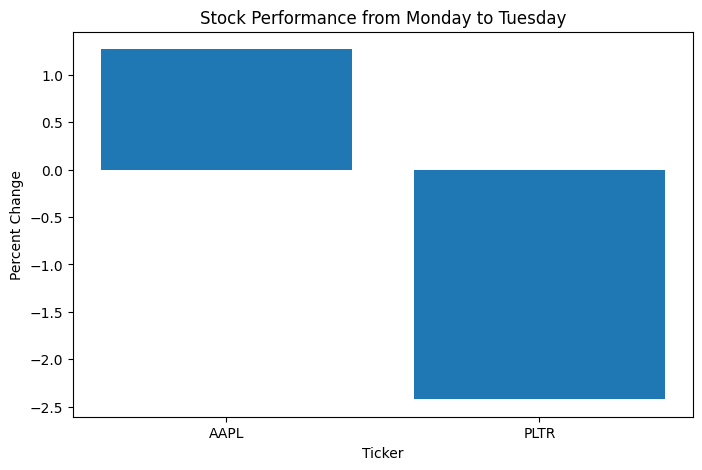

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(stock_summary["ticker"], stock_summary["percent_change"])
plt.title("Stock Performance from Monday to Tuesday")
plt.xlabel("Ticker")
plt.ylabel("Percent Change")
plt.show()

### Next I will do the same for company news data by sentiment and article count

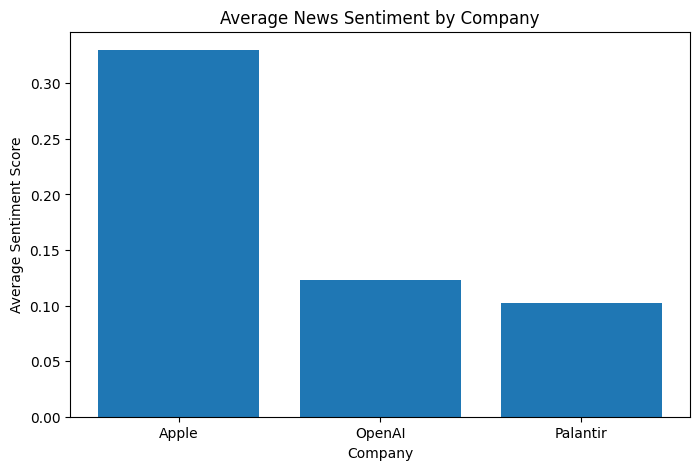

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(sentiment_summary["company"], sentiment_summary["average_sentiment"])
plt.title("Average News Sentiment by Company")
plt.xlabel("Company")
plt.ylabel("Average Sentiment Score")
plt.show()

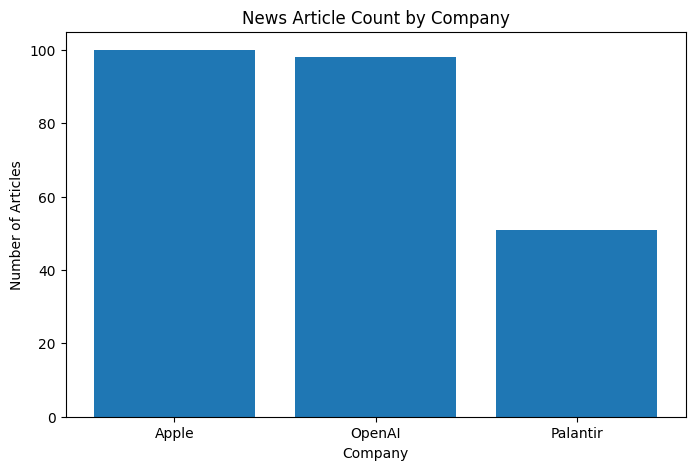

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(sentiment_summary["company"], sentiment_summary["article_count"])
plt.title("News Article Count by Company")
plt.xlabel("Company")
plt.ylabel("Number of Articles")
plt.show()

Based on the analysis, I can see that news sentiment has an inconsistent relationship with short-term stock performance. Apple had the highest average sentiment score at approximately 0.33 and also experienced a positive price change of about 1.3 percent, suggesting some alignment between positive sentiment and stock performance. However, Palantir had a positive sentiment score of approximately 0.10 while its stock price decreased by about 2.4 percent, indicating that positive sentiment did not translate into positive market movement.

OpenAI, while not publicly traded, had a high volume of news articles and a moderate sentiment score, which suggests strong media attention and public interest. This supports its use as a sentiment marker rather than a direct performance comparison.

The results indicate that while sentiment can provide insight into market perception, it is not a reliable predictor of short-term stock performance, as other external factors likely influence price movement.